# Data Setting

### Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스

import warnings

# 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings('ignore', category=FutureWarning)

### Load data

In [2]:
import pandas as pd
import glob
import os

# 데이터 파일이 저장된 폴더 경로
path = './Data'

# CSV 파일 검색
file_list = glob.glob(os.path.join(path, '20*.csv'))

print(f"찾은 CSV 파일 개수: {len(file_list)}")
print(f"파일 목록: {file_list}")

all_data_frames = []

for file in file_list:
    try:
        df_single_year = pd.read_csv(file, encoding='utf-8', low_memory=False)
        all_data_frames.append(df_single_year)
    except UnicodeDecodeError:
        try:
            df_single_year = pd.read_csv(file, encoding='cp949', low_memory=False)
            all_data_frames.append(df_single_year)
        except Exception as e:
            print(f"  [실패] '{os.path.basename(file)}' 파일은 두 인코딩 모두 실패: {e}")

# 파일이 성공적으로 하나라도 읽혔다면 데이터 통합을 진행
if all_data_frames:
    df_combined = pd.concat(all_data_frames, ignore_index=True)
    print(f"\n통합된 데이터프레임 크기: {df_combined.shape}")
    
else:
    print("\n통합할 데이터가 없습니다. 파일 경로 또는 파일 내용을 확인해주세요.")

df = df_combined.copy()

찾은 CSV 파일 개수: 8
파일 목록: ['./Data/2020.csv', './Data/2021.csv', './Data/2023.csv', './Data/2022.csv', './Data/2025.csv', './Data/2019.csv', './Data/2018.csv', './Data/2024.csv']

통합된 데이터프레임 크기: (4005951, 30)


### Data Structure

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005951 entries, 0 to 4005950
Data columns (total 30 columns):
 #   Column     Dtype  
---  ------     -----  
 0   접수년도       int64  
 1   자치구코드      float64
 2   자치구명       object 
 3   법정동코드      float64
 4   법정동명       object 
 5   지번구분코드     float64
 6   지번구분       object 
 7   본번         float64
 8   부번         float64
 9   층          float64
 10  계약일        int64  
 11  전월세구분      object 
 12  임대면적       float64
 13  보증금(만원)    int64  
 14  임대료(만원)    int64  
 15  건물명        object 
 16  건축년도       float64
 17  건물용도       object 
 18  계약기간       object 
 19  신규계약구분     object 
 20  갱신청구권사용    object 
 21  종전보증금      float64
 22  종전임대료      float64
 23  지번구분명      object 
 24  전월세 구분     object 
 25  임대면적(㎡)    float64
 26  신규갱신여부     object 
 27  계약갱신권사용여부  object 
 28  종전 보증금     float64
 29  종전 임대료     float64
dtypes: float64(13), int64(4), object(13)
memory usage: 916.9+ MB


In [4]:
df['접수년도'].unique()

array([2020, 2021, 2023, 2022, 2025, 2019, 2018, 2024])

In [5]:
print("--- DataFrame의 실제 컬럼명 ---")
print(df.columns)

--- DataFrame의 실제 컬럼명 ---
Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료', '지번구분명',
       '전월세 구분', '임대면적(㎡)', '신규갱신여부', '계약갱신권사용여부', '종전 보증금', '종전 임대료'],
      dtype='object')


In [6]:
print(df.head(5))

   접수년도    자치구코드 자치구명    법정동코드   법정동명  지번구분코드 지번구분      본번    부번     층  ...  \
0  2020  11170.0  용산구  11300.0  원효로2가     1.0   대지     1.0   0.0   6.0  ...   
1  2020  11440.0  마포구  11000.0   노고산동     1.0   대지     1.0   1.0   9.0  ...   
2  2020  11440.0  마포구  11000.0   노고산동     1.0   대지     1.0   1.0  10.0  ...   
3  2020  11590.0  동작구  10700.0    사당동     1.0   대지  1007.0  19.0   7.0  ...   
4  2020  11590.0  동작구  10700.0    사당동     1.0   대지  1007.0  19.0   3.0  ...   

   갱신청구권사용 종전보증금  종전임대료  지번구분명  전월세 구분 임대면적(㎡)  신규갱신여부 계약갱신권사용여부 종전 보증금 종전 임대료  
0      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
1      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
2      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
3      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  
4      NaN   NaN    NaN    NaN     NaN     NaN     NaN       NaN    NaN    NaN  

[5 rows x 30 columns]


## Data Cleaning & Preparation

In [7]:
# 필요한 데이터 선택
selected_columns = ['접수년도', '자치구명', '법정동명', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물용도']
df = df[selected_columns]
print(df.head(3))

   접수년도 자치구명   법정동명 전월세구분   임대면적  보증금(만원)  임대료(만원)  건물용도
0  2020  용산구  원효로2가    전세  22.03     5000        0  오피스텔
1  2020  마포구   노고산동    전세  33.66    18500        0  오피스텔
2  2020  마포구   노고산동    전세  41.04    22000        0  오피스텔


In [8]:
# 법정동명 확인
#print(df['법정동명'].unique())

# 원하는 동이 있는지 확인
target_dong = '합정동'
if target_dong in df['법정동명'].values:
    print(f"'{target_dong}' 동이 데이터에 존재합니다.")
else:
    print(f"'{target_dong}' 동이 데이터에 존재하지 않습니다.")

'합정동' 동이 데이터에 존재합니다.


In [9]:
# 결측치 및 이상치 처리
print(df.isnull().sum())
df = df.dropna()
df = df[df['임대면적'] > 0]

접수년도            0
자치구명            3
법정동명            3
전월세구분      448204
임대면적       448195
보증금(만원)         0
임대료(만원)         0
건물용도            0
dtype: int64


### 임대면적 분포

Text(0.5, 1.0, '임대면적 분포')

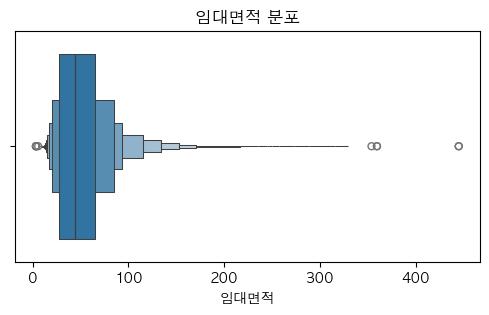

In [10]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포')

Text(0.5, 1.0, '임대면적 분포 (이상치 제거 후)')

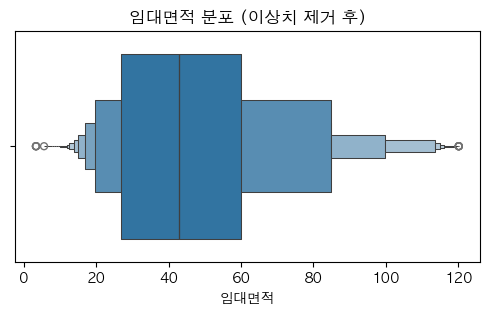

In [11]:
# 이상치 제거
q1 = df['임대면적'].quantile(0.25)
q3 = df['임대면적'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['임대면적'] >= lower_bound) & (df['임대면적'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대면적'])
plt.title('임대면적 분포 (이상치 제거 후)')

### 입대료 분포


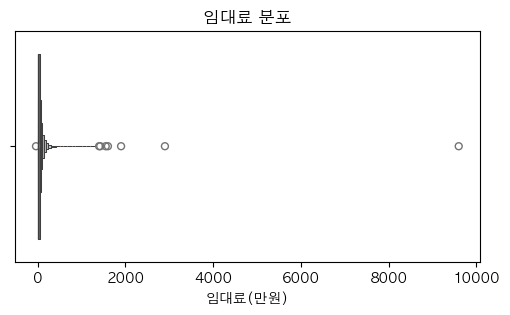

In [12]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포')
plt.show()

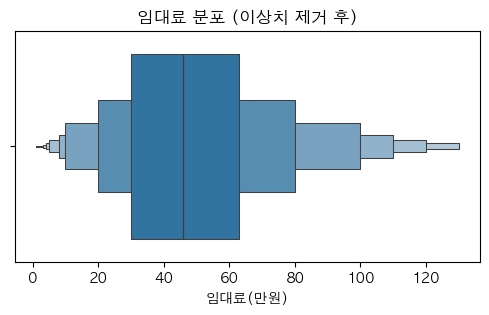

In [13]:
# 음수 및 임대료가 없는 경우 제거
df = df[df['임대료(만원)'] > 0]

# 이상치 제거
q1 = df['임대료(만원)'].quantile(0.25)
q3 = df['임대료(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr

df = df[(df['임대료(만원)'] >= lower_bound) & (df['임대료(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['임대료(만원)'])
plt.title('임대료 분포 (이상치 제거 후)')
plt.show()

### 보증금 분포

Text(0.5, 1.0, '보증금 분포')

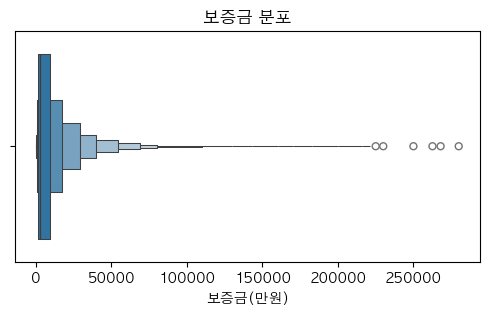

In [14]:
plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포')

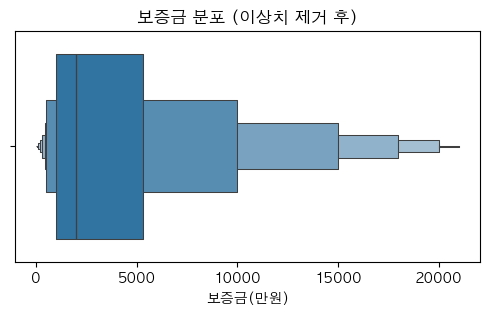

In [15]:
# 음수 보증금 제거
df = df[df['보증금(만원)'] > 0]


# 이상치 제거
q1 = df['보증금(만원)'].quantile(0.25)
q3 = df['보증금(만원)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr ; upper_bound = q3 + 1.5 * iqr
df = df[(df['보증금(만원)'] >= lower_bound) & (df['보증금(만원)'] <= upper_bound)]

plt.figure(figsize=(6, 3))
sns.boxenplot(x=df['보증금(만원)'])
plt.title('보증금 분포 (이상치 제거 후)')
plt.show()

## Feature Engineering

### 단위면적당 월세

월세 가격을 공정하게 비교하기 위해 표준화 작업을 실시
- 월세를 면적으로 나누어 1제곱미터 당 가격 계산

In [16]:
# 단위면적당 월세 계산
df['단위면적당_월세'] = df['임대료(만원)'] / df['임대면적']

# 무한대 및 NaN 값 제거
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['단위면적당_월세'])

print("'단위면적당_월세' 컬럼 생성 완료!")
print(df[['임대면적', '임대료(만원)', '단위면적당_월세']].head())

'단위면적당_월세' 컬럼 생성 완료!
     임대면적  임대료(만원)  단위면적당_월세
3   16.13       24  1.487911
10  15.84        5  0.315657
13  28.80       60  2.083333
14  28.80       10  0.347222
15  28.80       50  1.736111


### 대학가 컬럼 생성

In [17]:
print("법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...")

# 1. '대학가'라는 새로운 컬럼을 생성
df['대학가'] = ''

# 2. 각 대학가에 해당하는 법정동 목록을 정의
univ_dong_map = {
    '서울시립대': ['전농동', '답십리동', '휘경동', '청량리동'],
    '서울교대': ['서초동'],
    '서울대': ['신림동', '봉천동'],
    '홍익대': ['상수동', '서교동', '합정동']
}

# 3. 각 대학가의 법정동에 해당하는 행에 '대학가' 이름을 부여
for univ_name, dong_list in univ_dong_map.items():
    mask = df['법정동명'].isin(dong_list)
    df.loc[mask, '대학가'] = univ_name

# 4. '대학가' 컬럼이 비어있지 않은 행만 선택하여 새로운 데이터프레임 생성
df_analysis = df[df['대학가'] != ''].copy()

print("   - 생성 및 필터링 완료!")

# --- 최종 결과 확인 ---
print("\n--- 최종 분석용 데이터 정보 ---")
df_analysis.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(df_analysis['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 (상위 5개) ---")
# '법정동명'이 '대학가'에 잘 매칭되었는지 확인
print(df_analysis[['자치구명', '법정동명', '대학가', '단위면적당_월세']].head())

법정동명을 기준으로 '대학가' 변수 생성 및 데이터 필터링 중...
   - 생성 및 필터링 완료!

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 162752 entries, 173 to 4005857
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   접수년도      162752 non-null  int64  
 1   자치구명      162752 non-null  object 
 2   법정동명      162752 non-null  object 
 3   전월세구분     162752 non-null  object 
 4   임대면적      162752 non-null  float64
 5   보증금(만원)   162752 non-null  int64  
 6   임대료(만원)   162752 non-null  int64  
 7   건물용도      162752 non-null  object 
 8   단위면적당_월세  162752 non-null  float64
 9   대학가       162752 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 13.7+ MB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      112891
서울시립대     24869
서울교대      12589
홍익대       12403
Name: count, dtype: int64

--- 최종 데이터 샘플 (상위 5개) ---
    자치구명 법정동명  대학가  단위면적당_월세
173  관악구  신림동  서울대  2.217295
177  관악구  신림동  서울대  0.240674
178  관악구  신림동  서울대  0.060168
179  관악구 

# EDA

### 대학가별 단위면적당 월세 분포 확인

In [18]:
print(df_analysis['대학가'].value_counts())

대학가
서울대      112891
서울시립대     24869
서울교대      12589
홍익대       12403
Name: count, dtype: int64


In [19]:
# '단위면적당_월세'의 기술 통계량 확인
print(df_analysis['단위면적당_월세'].describe())

count    162752.000000
mean          1.850590
std           1.086152
min           0.014215
25%           1.001603
50%           1.750000
75%           2.500000
max          12.054507
Name: 단위면적당_월세, dtype: float64


### Correlation Plot

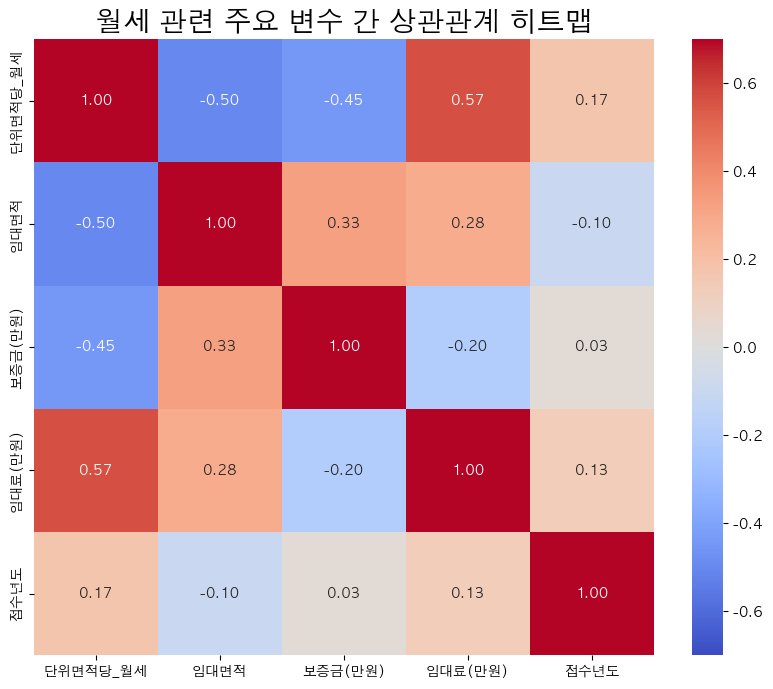

In [20]:
# 1. 수치형 변수 선택
numerical_cols = ['단위면적당_월세', '임대면적', '보증금(만원)', '임대료(만원)', '접수년도']
correlation_data = df_analysis[numerical_cols]

# 2. 상관 행렬 계산
correlation_matrix = correlation_data.corr()

# 3. 히트맵으로 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.7, vmax=0.7)
plt.title('월세 관련 주요 변수 간 상관관계 히트맵', fontsize=20)
plt.show()

### 대학가별 단위면적당 월세 분포 Violin Plot

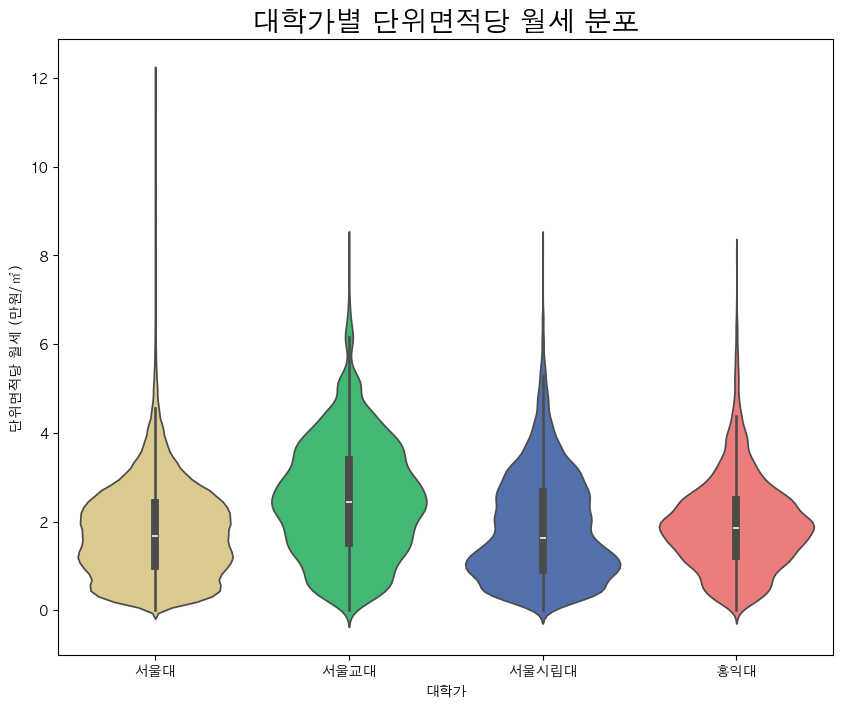

In [21]:
# plotting
plt.figure(figsize=(10, 8))
sns.violinplot(x='대학가', y='단위면적당_월세', data=df_analysis, 
               palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'])
plt.title('대학가별 단위면적당 월세 분포', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('단위면적당 월세 (만원/㎡)')
plt.show()

### 평균비교

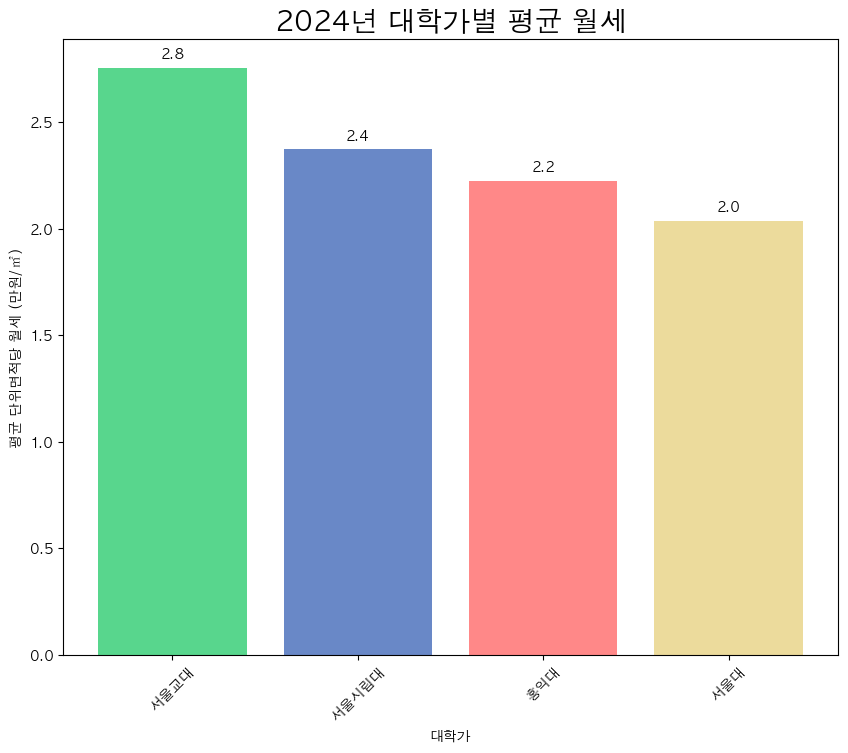

In [22]:
# 2024년 데이터 만 필터링
df_all_univ_2024 = df_analysis[df_analysis['접수년도'] == 2024]

# 평균 비교 막대그래프
plt.figure(figsize=(10, 8))
mean_by_univ = df_all_univ_2024.groupby('대학가')['단위면적당_월세'].mean().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(mean_by_univ.index, mean_by_univ.values, color=['#2ECC71', '#436BBA', '#FF6B6B', '#E8D284'], alpha=0.8)
plt.title('2024년 대학가별 평균 월세', fontsize=20)
plt.xlabel('대학가')
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.xticks(rotation=45)

# 막대 위에 수치 표시
for bar, value in zip(bars, mean_by_univ.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

plt.show()


## 신뢰도 분석

### Bootstrap

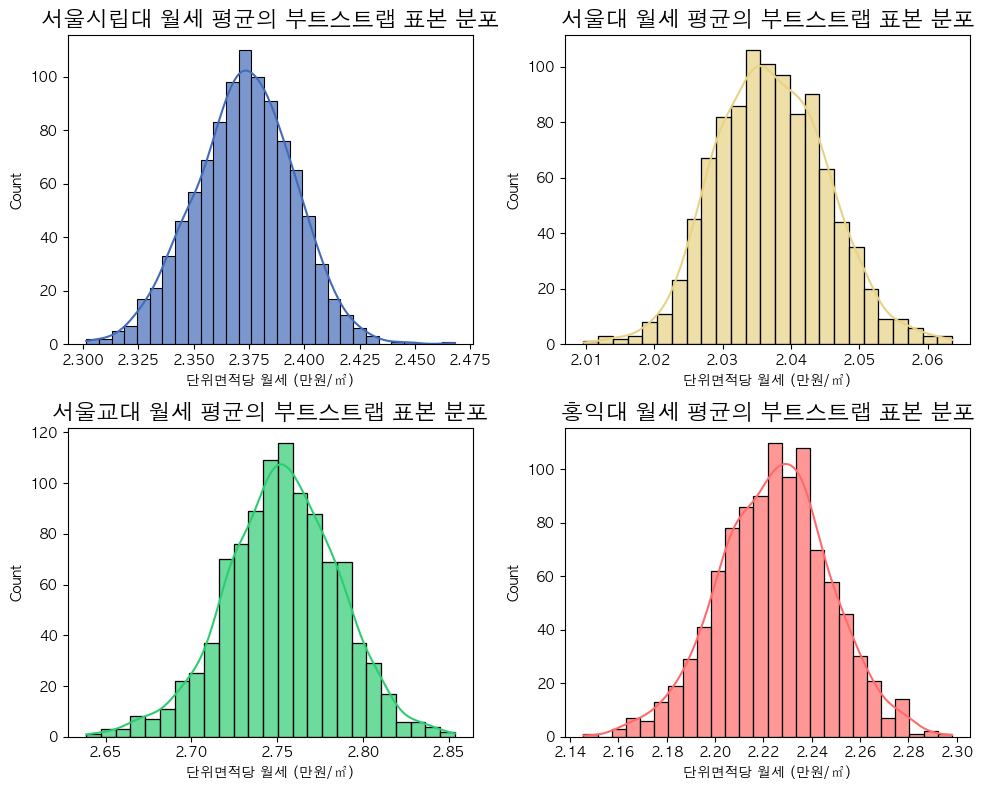

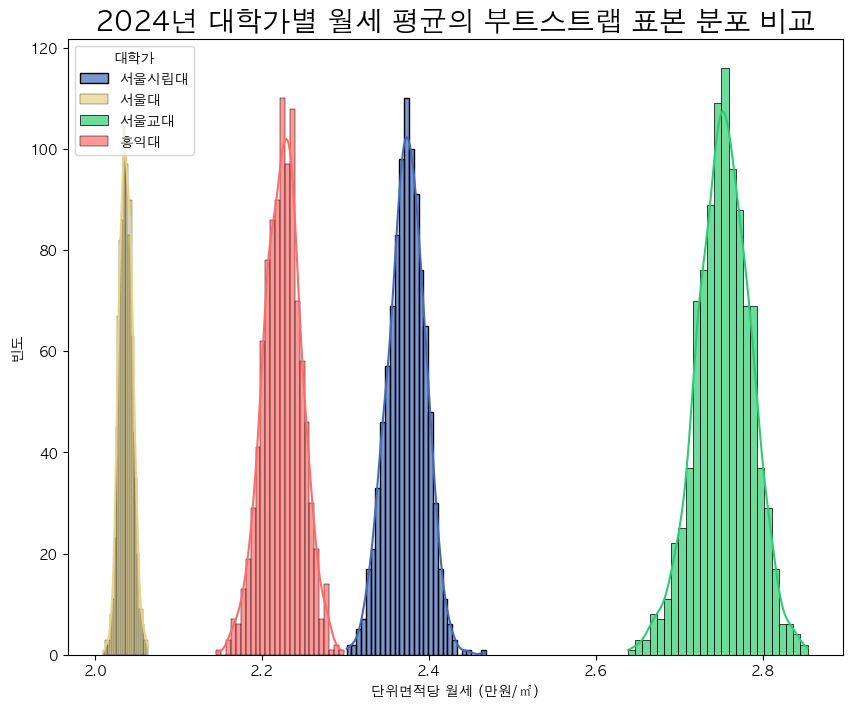

In [23]:
# 2024년 각 대학가별 데이터 분리
df_seoul_city_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울시립대']
df_seoul_nat_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울대']
df_seoul_edu_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '서울교대']
df_hongik_2024 = df_all_univ_2024[df_all_univ_2024['대학가'] == '홍익대']

# 모든 대학가에 대해 부트스트랩 수행
universities = ['서울시립대', '서울대', '서울교대', '홍익대']
datasets = [df_seoul_city_2024, df_seoul_nat_2024, 
            df_seoul_edu_2024, df_hongik_2024]
bootstrap_results = {}

for univ, data in zip(universities, datasets):
    bootstrap_means = []
    for _ in range(1000):
        sample = data['단위면적당_월세'].sample(n=len(data), replace=True)
        bootstrap_means.append(sample.mean())
    bootstrap_results[univ] = bootstrap_means

# 시각화
plt.figure(figsize=(10, 8))

colors=['#436BBA', '#E8D284', '#2ECC71', '#FF6B6B']

# 개별 대학가별 부트스트랩 분포
for i, (univ, color) in enumerate(zip(universities, colors)):
    plt.subplot(2, 2, i+1)
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, color=color)
    plt.title(f'{univ} 월세 평균의 부트스트랩 표본 분포', fontsize=16)
    plt.xlabel('단위면적당 월세 (만원/㎡)')

plt.tight_layout()
plt.show()

# 모든 대학가 부트스트랩 결과를 하나의 그래프로 비교
plt.figure(figsize=(10, 8))

for univ, color in zip(universities, colors):
    sns.histplot(bootstrap_results[univ], kde=True, alpha=0.7, label=univ, color=color)

plt.title('2024년 대학가별 월세 평균의 부트스트랩 표본 분포 비교', fontsize=20)
plt.xlabel('단위면적당 월세 (만원/㎡)')
plt.ylabel('빈도')
plt.legend(title='대학가')
plt.show()

### 각 대학별 95% 신뢰구간 계산

In [24]:
for univ in universities:
    bootstrap_means_univ = bootstrap_results[univ]
    
    # 95% 신뢰구간 계산
    lower_bound = np.percentile(bootstrap_means_univ, 2.5)
    upper_bound = np.percentile(bootstrap_means_univ, 97.5)
    
    # 표준오차 계산
    std_error = np.std(bootstrap_means_univ)
    
    # 평균 계산
    mean_val = np.mean(bootstrap_means_univ)
    
    print(f"=== {univ} ===")
    print(f"단위면적당 월세 평균: {mean_val:.2f} 만원")
    print(f"95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}] 만원")
    print(f"표준오차: {std_error:.2f} 만원")
    print()

=== 서울시립대 ===
단위면적당 월세 평균: 2.37 만원
95% 신뢰구간: [2.33, 2.42] 만원
표준오차: 0.02 만원

=== 서울대 ===
단위면적당 월세 평균: 2.04 만원
95% 신뢰구간: [2.02, 2.05] 만원
표준오차: 0.01 만원

=== 서울교대 ===
단위면적당 월세 평균: 2.75 만원
95% 신뢰구간: [2.68, 2.81] 만원
표준오차: 0.03 만원

=== 홍익대 ===
단위면적당 월세 평균: 2.22 만원
95% 신뢰구간: [2.18, 2.27] 만원
표준오차: 0.02 만원



### QQ plot

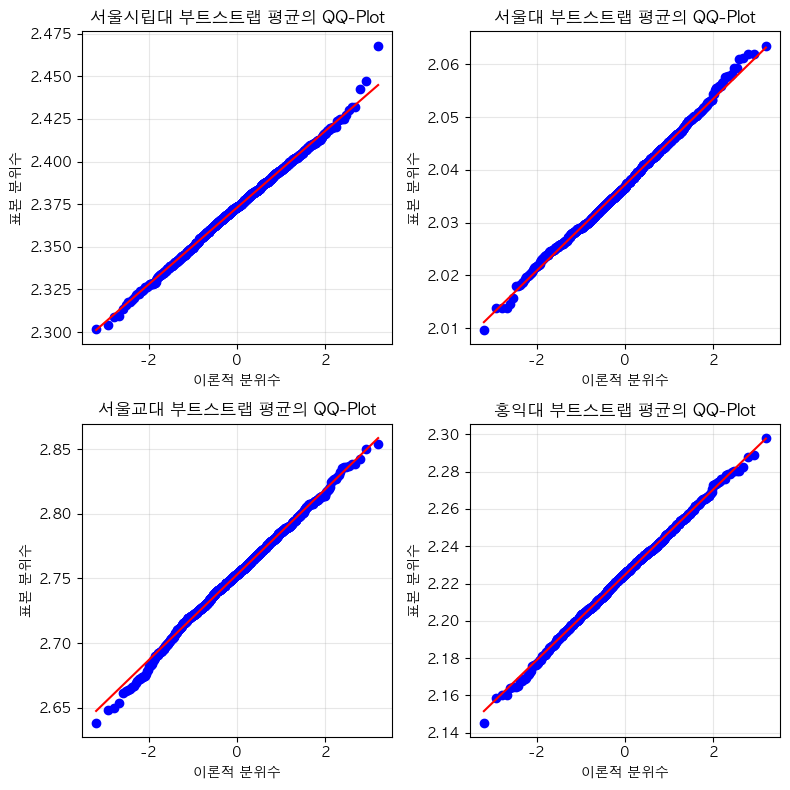

In [25]:
from scipy import stats

plt.figure(figsize=(8, 8))

# 각 대학가별 QQ-Plot
for i, univ in enumerate(universities):
    plt.subplot(2, 2, i+1)
    stats.probplot(bootstrap_results[univ], dist="norm", plot=plt)
    plt.title(f'{univ} 부트스트랩 평균의 QQ-Plot')
    plt.xlabel('이론적 분위수')
    plt.ylabel('표본 분위수')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 연도별 대학가 단위면적당 월세 변화 분석

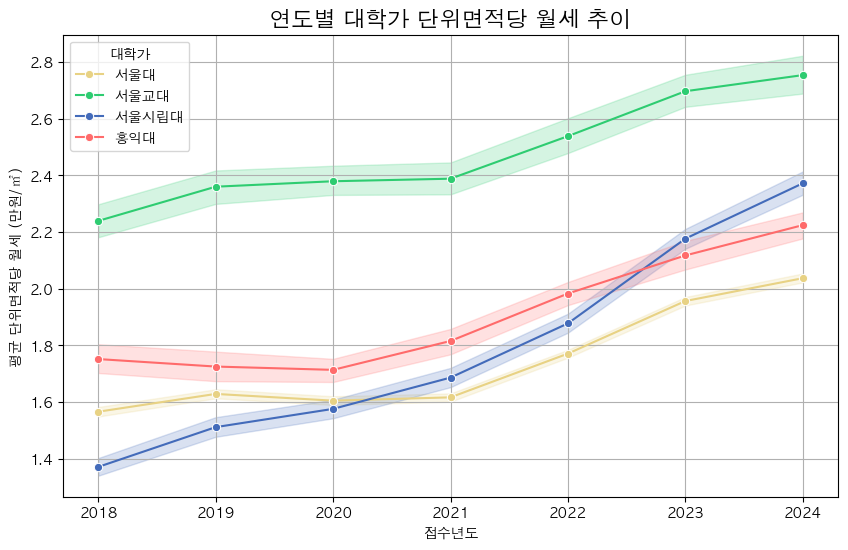

In [26]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='접수년도', y='단위면적당_월세', hue='대학가', data=df_analysis, estimator=np.mean, palette=['#E8D284', '#2ECC71', '#436BBA', '#FF6B6B'], marker='o')
plt.title('연도별 대학가 단위면적당 월세 추이', fontsize=16)
plt.ylabel('평균 단위면적당 월세 (만원/㎡)')
plt.grid(True)
plt.show()

### 월세 증가율

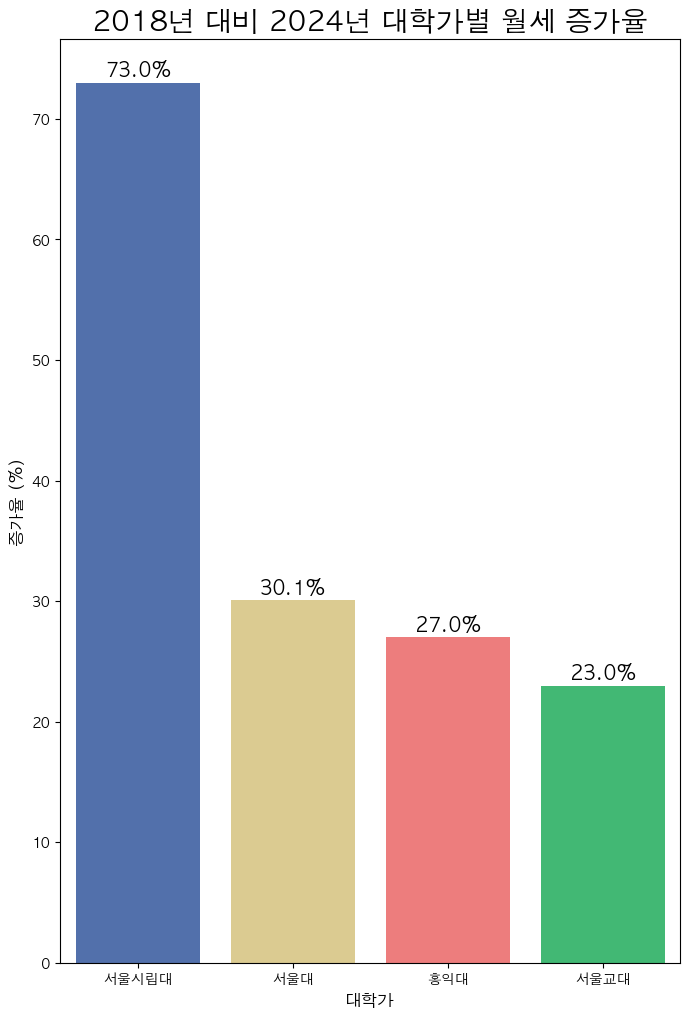

In [27]:
# 1. 증가율 계산
start_year = df_analysis['접수년도'].min()
end_year = df_analysis['접수년도'].max()

rent_start = df_analysis[df_analysis['접수년도'] == start_year].groupby('대학가')['단위면적당_월세'].mean()
rent_end = df_analysis[df_analysis['접수년도'] == end_year].groupby('대학가')['단위면적당_월세'].mean()

increase_rate = ((rent_end - rent_start) / rent_start) * 100

# 2. 증가율을 내림차순으로 정렬
sorted_increase_rate = increase_rate.sort_values(ascending=False)

# 3. 막대그래프로 시각화
plt.figure(figsize=(8, 12))
ax = sns.barplot(x=sorted_increase_rate.index, y=sorted_increase_rate.values, order=sorted_increase_rate.index, palette=['#436BBA', '#E8D284', '#FF6B6B', '#2ECC71'])

# 그래프 제목 및 축 레이블 설정
plt.title(f'{start_year}년 대비 {end_year}년 대학가별 월세 증가율', fontsize=20)
plt.ylabel('증가율 (%)', fontsize=12)
plt.xlabel('대학가', fontsize=12)
plt.xticks(rotation=0)

# 막대 위에 퍼센트 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',    # 표시할 텍스트
                (p.get_x() + p.get_width() / 2., p.get_height()), # 텍스트 위치
                ha='center', va='center',   # 정렬
                xytext=(0, 9),              # 막대 끝에서 약간 위로
                textcoords='offset points',
                fontsize=14)                
plt.show()

# Hypothesis test 

## 가설1 
: 2024년도 평균월세 차이는 과연 통계적으로 유의미한가? 

In [28]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_2024 = df_all_univ_2024.copy()

### 가설 1-A: 서울교대 vs. 서울대 (두 그룹 비교, t-test)

- 평균 월세가 가장 많이 차이나는 두 그룹을 비교

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울대}$ (두 대학가 간 평균 월세 차이가 없다.)

대립가설($H_1$): $\mu_{서울교대} > \mu_{서울대}$ (서울교대 인근 평균 월세가 더 비싸다.)

In [29]:
# --- [ 가설 1-A 검증: Independent Two-sample t-test ] ---
print("--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---")

# 1. 각 그룹의 샘플 데이터를 추출
rent_snu_edu = df_2024[df_2024['대학가'] == '서울교대']['단위면적당_월세']
rent_snu = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']

# 2. 등분산성 검정 (Levene's Test)
#    - p-value가 0.05보다 작으면 분산이 다르다고 가정 (equal_var=False).
levene_stat, levene_p = stats.levene(rent_snu_edu, rent_snu)
equal_var_flag = levene_p > 0.05 # True이면 등분산 가정, False이면 이분산 가정(Welch's T-test)

print(f"[등분산성 검정] p-value: {levene_p:.4f} (equal_var={equal_var_flag})")

# 3. Independent Two-sample t-test 수행
#    - alternative='greater': 서울교대(첫번째 인자)의 평균이 서울시립대(두번째 인자)보다 크다는 단측 검정
t_stat_1a, p_val_1a = stats.ttest_ind(
    rent_snu_edu, 
    rent_snu, 
    equal_var=equal_var_flag, 
    alternative='greater'
)

print(f"t-statistic: {t_stat_1a:.4f}")
print(f"p-value: {p_val_1a:.4f}")

# 4. 결과 해석
alpha = 0.05
if p_val_1a < alpha:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세는 서울시립대 인근보다 통계적으로 유의미하게 비쌉니다.")
else:
    print(f"▶ 결론: p-value({p_val_1a:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 2024년 기준 서울교대 인근의 평균 월세가 서울시립대 인근보다 유의미하게 비싸다고 말할 수 없습니다.")

--- 🔬 가설 1-A 검증 (서울교대 vs 서울시립대) ---
[등분산성 검정] p-value: 0.1697 (equal_var=True)
t-statistic: 9.5831
p-value: 0.0000
▶ 결론: p-value(0.0000)가 유의수준(0.05)보다 작으므로 귀무가설을 기각합니다.
   따라서, 2024년 기준 서울교대 인근의 평균 월세는 서울시립대 인근보다 통계적으로 유의미하게 비쌉니다.


--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---


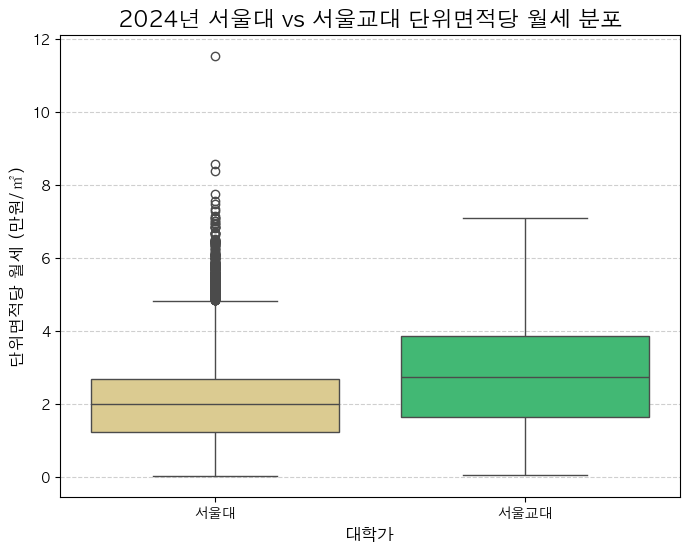

In [30]:
# --- [ 가설 1-A 시각화: Box Plot ] ---
print("--- 📊 가설 1-A 시각화 (서울교대 vs 서울대) ---")

# 1. t-test에 사용된 두 그룹('서울대', '서울교대') 데이터만 필터링
df_1a_viz = df_2024[df_2024['대학가'].isin(['서울대', '서울교대'])]

# 2. Box Plot으로 두 그룹의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='대학가', 
    y='단위면적당_월세', 
    data=df_1a_viz, 
    palette=['#E8D284', '#2ECC71'], # EDA.ipynb의 [22]번 셀 색상 팔레트와 일치
    order=['서울대', '서울교대'] # 순서 지정
)

plt.title('2024년 서울대 vs 서울교대 단위면적당 월세 분포', fontsize=16)
plt.xlabel('대학가', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 1-B: 4개 대학가 전체 비교 (ANOVA)

귀무가설($H_0$): $\mu_{서울교대} = \mu_{서울시립대} = \mu_{서울대} = \mu_{홍익대}$ 
    (모든 대학가 간 평균 월세가 동일하다.)

대립가설($H_1$): 모든 대학가의 평균 월세가 동일한 것은 아니다. (적어도 하나는 다르다.)

In [31]:
# --- [ 가설 1-B 검증: ANOVA 및 Tukey's HSD 사후 검정 ] ---
print("\n--- 가설 1-B 검증 (4개 대학가 전체 비교) ---")

# 1. ANOVA 검증을 위해 나머지 대학가 데이터도 추출
rent_uos = df_2024[df_2024['대학가'] == '서울시립대']['단위면적당_월세']
rent_hongik = df_2024[df_2024['대학가'] == '홍익대']['단위면적당_월세']

# 2. 일원배치 분산분석 (One-way ANOVA) 수행
f_stat_1b, p_val_1b = stats.f_oneway(rent_snu_edu, rent_snu, rent_uos, rent_hongik)

print(f"[ANOVA 검증] F-statistic: {f_stat_1b:.4f}")
print(f"p-value: {p_val_1b:.4f}")

# 3. ANOVA 결과 해석
if p_val_1b < alpha:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 작으므로 귀무가설을 기각합니다.")
    print("   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.")
    print("\n   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.")
    
    # 4. 사후 검정 (Tukey's HSD)
    #    - ANOVA가 유의미할 때만 실행하여 어떤 그룹끼리 차이가 나는지 확인
    tukey_result = pairwise_tukeyhsd(
        df_2024['단위면적당_월세'], 
        df_2024['대학가'], 
        alpha=0.05
    )
    
    print(tukey_result)
    
else:
    print(f"▶ 결론: p-value({p_val_1b:.4f})가 유의수준({alpha})보다 크므로 귀무가설을 기각할 수 없습니다.")
    print("   따라서, 4개 대학가 간 평균 월세 차이가 통계적으로 유의미하다고 말할 수 없습니다.")


--- 가설 1-B 검증 (4개 대학가 전체 비교) ---
[ANOVA 검증] F-statistic: 54.7572
p-value: 0.0000
▶ 결론: p-value(0.0000)가 유의수준(0.05)보다 작으므로 귀무가설을 기각합니다.
   따라서, 4개 대학가 간 평균 월세는 통계적으로 유의미한 차이가 있습니다.

   [사후 검정 (Tukey's HSD) 수행] - 어느 그룹 간에 차이가 있는지 확인합니다.
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  서울교대    서울대  -0.7169   0.0 -0.7901 -0.6436   True
  서울교대  서울시립대  -0.3818   0.0 -0.4661 -0.2975   True
  서울교대    홍익대  -0.5295   0.0 -0.6239 -0.4352   True
   서울대  서울시립대    0.335   0.0  0.2832  0.3869   True
   서울대    홍익대   0.1873   0.0  0.1203  0.2543   True
 서울시립대    홍익대  -0.1477   0.0 -0.2266 -0.0689   True
---------------------------------------------------


--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---


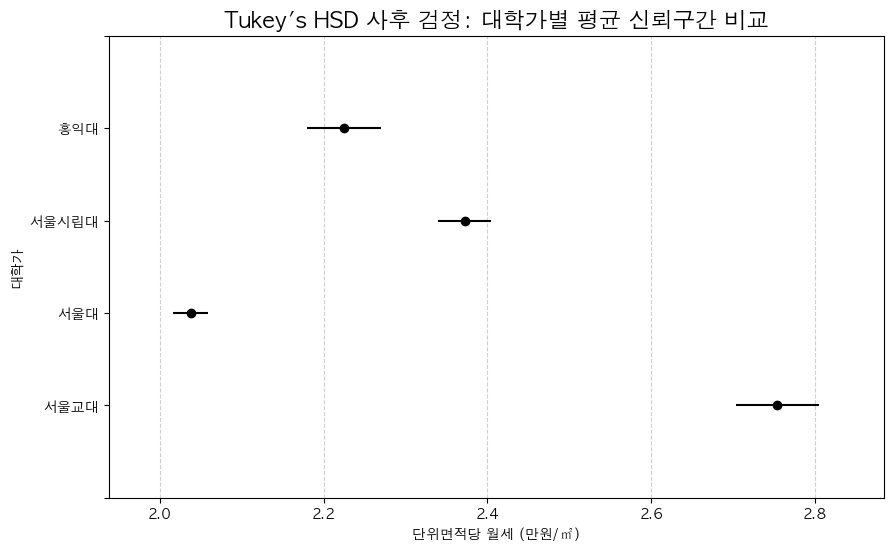

In [32]:
# --- [ 가설 1-B 시각화: Tukey's HSD Plot ] ---
print("--- 📊 가설 1-B 시각화 (Tukey's HSD 사후 검정) ---")

# 1. Tukey HSD 결과를 시각화합니다. (tukey_result 객체는 이전 셀에서 생성되어 있어야 함)
#    이 플롯은 각 그룹의 '평균'에 대한 95% 신뢰구간을 보여줍니다.
try:
    fig = tukey_result.plot_simultaneous(
        figsize=(10, 6), 
        xlabel='단위면적당 월세 (만원/㎡)',
        ylabel='대학가'
    )
    plt.title("Tukey's HSD 사후 검정: 대학가별 평균 신뢰구간 비교", fontsize=16)
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.show()

except NameError:
    print("오류: 'tukey_result' 객체가 정의되지 않았습니다. [가설 1-B] 코드를 먼저 실행하세요.")

▶ 위 결과에 따라 각 그룹 간의 차이가 모두 통계적으로 유의미한 차이임을 알 수 있다.

## 가설 2
: 서울시립대 인근의 '가파른 월세 상승' 검증

In [33]:
import statsmodels.formula.api as smf

# 전체 기간 데이터 사용
df_full = df_analysis.copy()

### 가설 2-A: 2021년 전/후 시점 비교 (A/B 테스트)

서울시립대 인근의 평균 월세는 2021년을 기점으로 통계적으로 유의미하게 상승했는가?

귀무가설($H_0$): $\mu_{2021이후} = \mu_{2021이전}$ (2021년 전후의 평균 월세 차이가 없다.)
     
대립가설($H_1$): $\mu_{2021이후} > \mu_{2021이전}$ (2021년 이후 평균 월세가 더 높다.)

In [34]:
# 간단 주석 버전
print("--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---")

# 서울시립대 데이터만
df_uos_full = df_full[df_full['대학가'] == '서울시립대']

# 2020년까지 = 이전, 2021년부터 = 이후
rent_pre_2021 = df_uos_full[df_uos_full['접수년도'] <= 2020]['단위면적당_월세']
rent_post_2021 = df_uos_full[df_uos_full['접수년도'] >= 2021]['단위면적당_월세']

# 등분산성 검사
levene_stat_2a, levene_p_2a = stats.levene(rent_post_2021, rent_pre_2021)
equal_var_flag_2a = levene_p_2a > 0.05
print(f"[등분산성 검정] p-value: {levene_p_2a:.4f} (equal_var={equal_var_flag_2a})")

# 단측 t-test: 이후 > 이전
t_stat_2a, p_val_2a = stats.ttest_ind(
    rent_post_2021,
    rent_pre_2021,
    equal_var=equal_var_flag_2a,
    alternative='greater'
)

print(f"t-statistic: {t_stat_2a:.4f}")
print(f"p-value: {p_val_2a:.4f}")

# 해석 (alpha는 이전 셀에서 정의한 값 사용)
if p_val_2a < alpha:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) < {alpha} → 귀무가설 기각. 2021년 이후 상승이 유의미함.")
else:
    print(f"▶ 결론: p-value({p_val_2a:.4f}) >= {alpha} → 귀무가설 기각 불가. 유의한 상승 아님.")


--- 🔬 가설 2-A 검증 (서울시립대 2021년 전/후 비교) ---
[등분산성 검정] p-value: 0.0000 (equal_var=False)
t-statistic: 39.8371
p-value: 0.0000
▶ 결론: p-value(0.0000) < 0.05 → 귀무가설 기각. 2021년 이후 상승이 유의미함.


--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---


/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_98412/3663711558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')


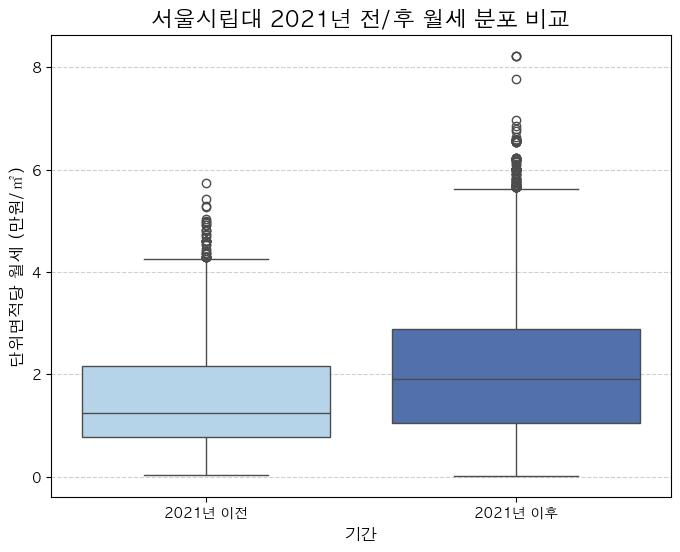

In [35]:
# --- [ 가설 2-A 시각화: Box Plot (2021년 전/후) ] ---
print("--- 📊 가설 2-A 시각화 (서울시립대 2021년 전/후) ---")

# 1. 시각화를 위해 '기간' 컬럼을 생성합니다. (df_uos_full은 이전 셀에서 생성)
df_uos_full['기간'] = np.where(df_uos_full['접수년도'] >= 2021, '2021년 이후', '2021년 이전')

# 2. Box Plot으로 두 기간의 분포를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='기간', 
    y='단위면적당_월세', 
    data=df_uos_full,
    palette=['#AED6F1', '#436BBA'], # 이전/이후 색상 지정
    order=['2021년 이전', '2021년 이후'] # 순서 지정
)

plt.title('서울시립대 2021년 전/후 월세 분포 비교', fontsize=16)
plt.xlabel('기간', fontsize=12)
plt.ylabel('단위면적당 월세 (만원/㎡)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### 가설 2-B: 타 대학가와의 '상승 추세' 비교 (회귀분석)

2021년 이후, 서울시립대 인근의 월세 상승폭은 서울대(대조군) 인근의 상승폭보다 통계적으로 유의미하게 더 컸는가?

귀무가설($H_0$): $\beta_3 = 0$ (서울시립대만의 추가적인 월세 상승 효과는 없다.)

대립가설($H_1$): $\beta_3 > 0$ (서울시립대만의 추가적인 월세 상승 효과가 유의미하게 존재한다.)

In [36]:
# --- [ 가설 2-B 검증: 회귀분석 (Difference-in-Differences) ] ---
print("\n--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---")

# 서울대와 서울시립대 데이터만 사용
df_did = df_full[df_full['대학가'].isin(['서울대', '서울시립대'])].copy()

# 더미 변수 생성: 2021년 이후, 서울시립대 여부
df_did['is_Post2021'] = (df_did['접수년도'] >= 2021).astype(int)
df_did['is_UOS'] = (df_did['대학가'] == '서울시립대').astype(int)

# DiD 회귀모형 (interaction 포함)
model = smf.ols(formula='단위면적당_월세 ~ is_Post2021 * is_UOS', data=df_did).fit()

# 결과 출력
print(model.summary())

# 상호작용항의 계수와 p-value 추출
interaction_term = 'is_Post2021:is_UOS'
interaction_coef = model.params[interaction_term]
interaction_pvalue = model.pvalues[interaction_term]

print(f"\n--- [ {interaction_term} ] 상호작용항 ---")
print(f"계수: {interaction_coef:.4f}")
print(f"p-value (양측): {interaction_pvalue:.4e}")

# 단측검정: 계수가 양수이고 (양측 p-value / 2) < alpha 이면 유의
p_val_one_sided = interaction_pvalue / 2

if (interaction_coef > 0) and (p_val_one_sided < alpha):
    print(f"▶ 결론: 계수 양수({interaction_coef:.4f})이고 단측 p-value({p_val_one_sided:.4e}) < {alpha} → 유의합니다.")
    print("   즉, 서울시립대의 2021년 이후 상승폭이 서울대보다 컸습니다.")
else:
    print("▶ 결론: 귀무가설을 기각할 수 없습니다. 서울시립대의 상승폭이 유의하게 더 크다고 보기 어렵습니다.")



--- 🔬 가설 2-B 검증 (서울시립대 vs 서울대 상승폭 비교) ---
                            OLS Regression Results                            
Dep. Variable:               단위면적당_월세   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1104.
Date:                Thu, 20 Nov 2025   Prob (F-statistic):               0.00
Time:                        23:58:30   Log-Likelihood:            -2.0080e+05
No. Observations:              137760   AIC:                         4.016e+05
Df Residuals:                  137756   BIC:                         4.017e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

▶ 회귀분석 결과, '서울시립대이면서 2021년 이후'를 나타내는 항의 계수가 +0.3057, 이 값의 p-valuerk 0.000 이다.

▶ 이는 2021년 이후 서울대, 홍익대, 서울교대 등 다른 대학가들이 공통적으로 겪은 월세 상승분(시간 효과, 0.4414)을 모두 제외하고도, 서울시립대 인근만 추가적으로 0.34 (만원/㎡)만큼 더 폭등했음을 의미

## 추가 분석

혜성, 신웅이 여기서부터 채우면 됨.

# Machine Learning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# 1. 분석 대상 데이터 준비
# 모델링에 사용할 변수 선정 (더 추가 가능)
features = ['접수년도', '임대면적', '보증금(만원)', '대학가', '건물용도']
target = '단위면적당_월세'

data_model = df_analysis[features + [target]].copy()

# 2. 범주형 변수 One-Hot Encoding (대학가, 건물용도)
data_model = pd.get_dummies(data_model, columns=['대학가', '건물용도'], drop_first=True)

# 3. Train/Test Split (시계열 특성 고려)
# 2024년 데이터를 Test set으로, 그 이전(2018~2023)을 Train set으로 설정
train_data = data_model[data_model['접수년도'] < 2024]
test_data = data_model[data_model['접수년도'] == 2024]

X_train = train_data.drop(target, axis=1)
y_train = train_data[target]

X_test = test_data.drop(target, axis=1)
y_test = test_data[target]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 134494, Test samples: 28258


In [ ]:
# 4. GradientBoostingRegressor로 학습
## n_estimators: 트리의 개수, learning_rate: 학습률, max_depth: 트리의 깊이
model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. 2024년 데이터로 성능 평가
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance (2024년 데이터 기준):")
print(f"RMSE: {rmse:.4f} (단위: 만원/㎡)")
print(f"R^2 Score: {r2:.4f}")

Model Performance (2024년 데이터 기준):
RMSE: 0.6400 (단위: 만원/㎡)
R^2 Score: 0.7217


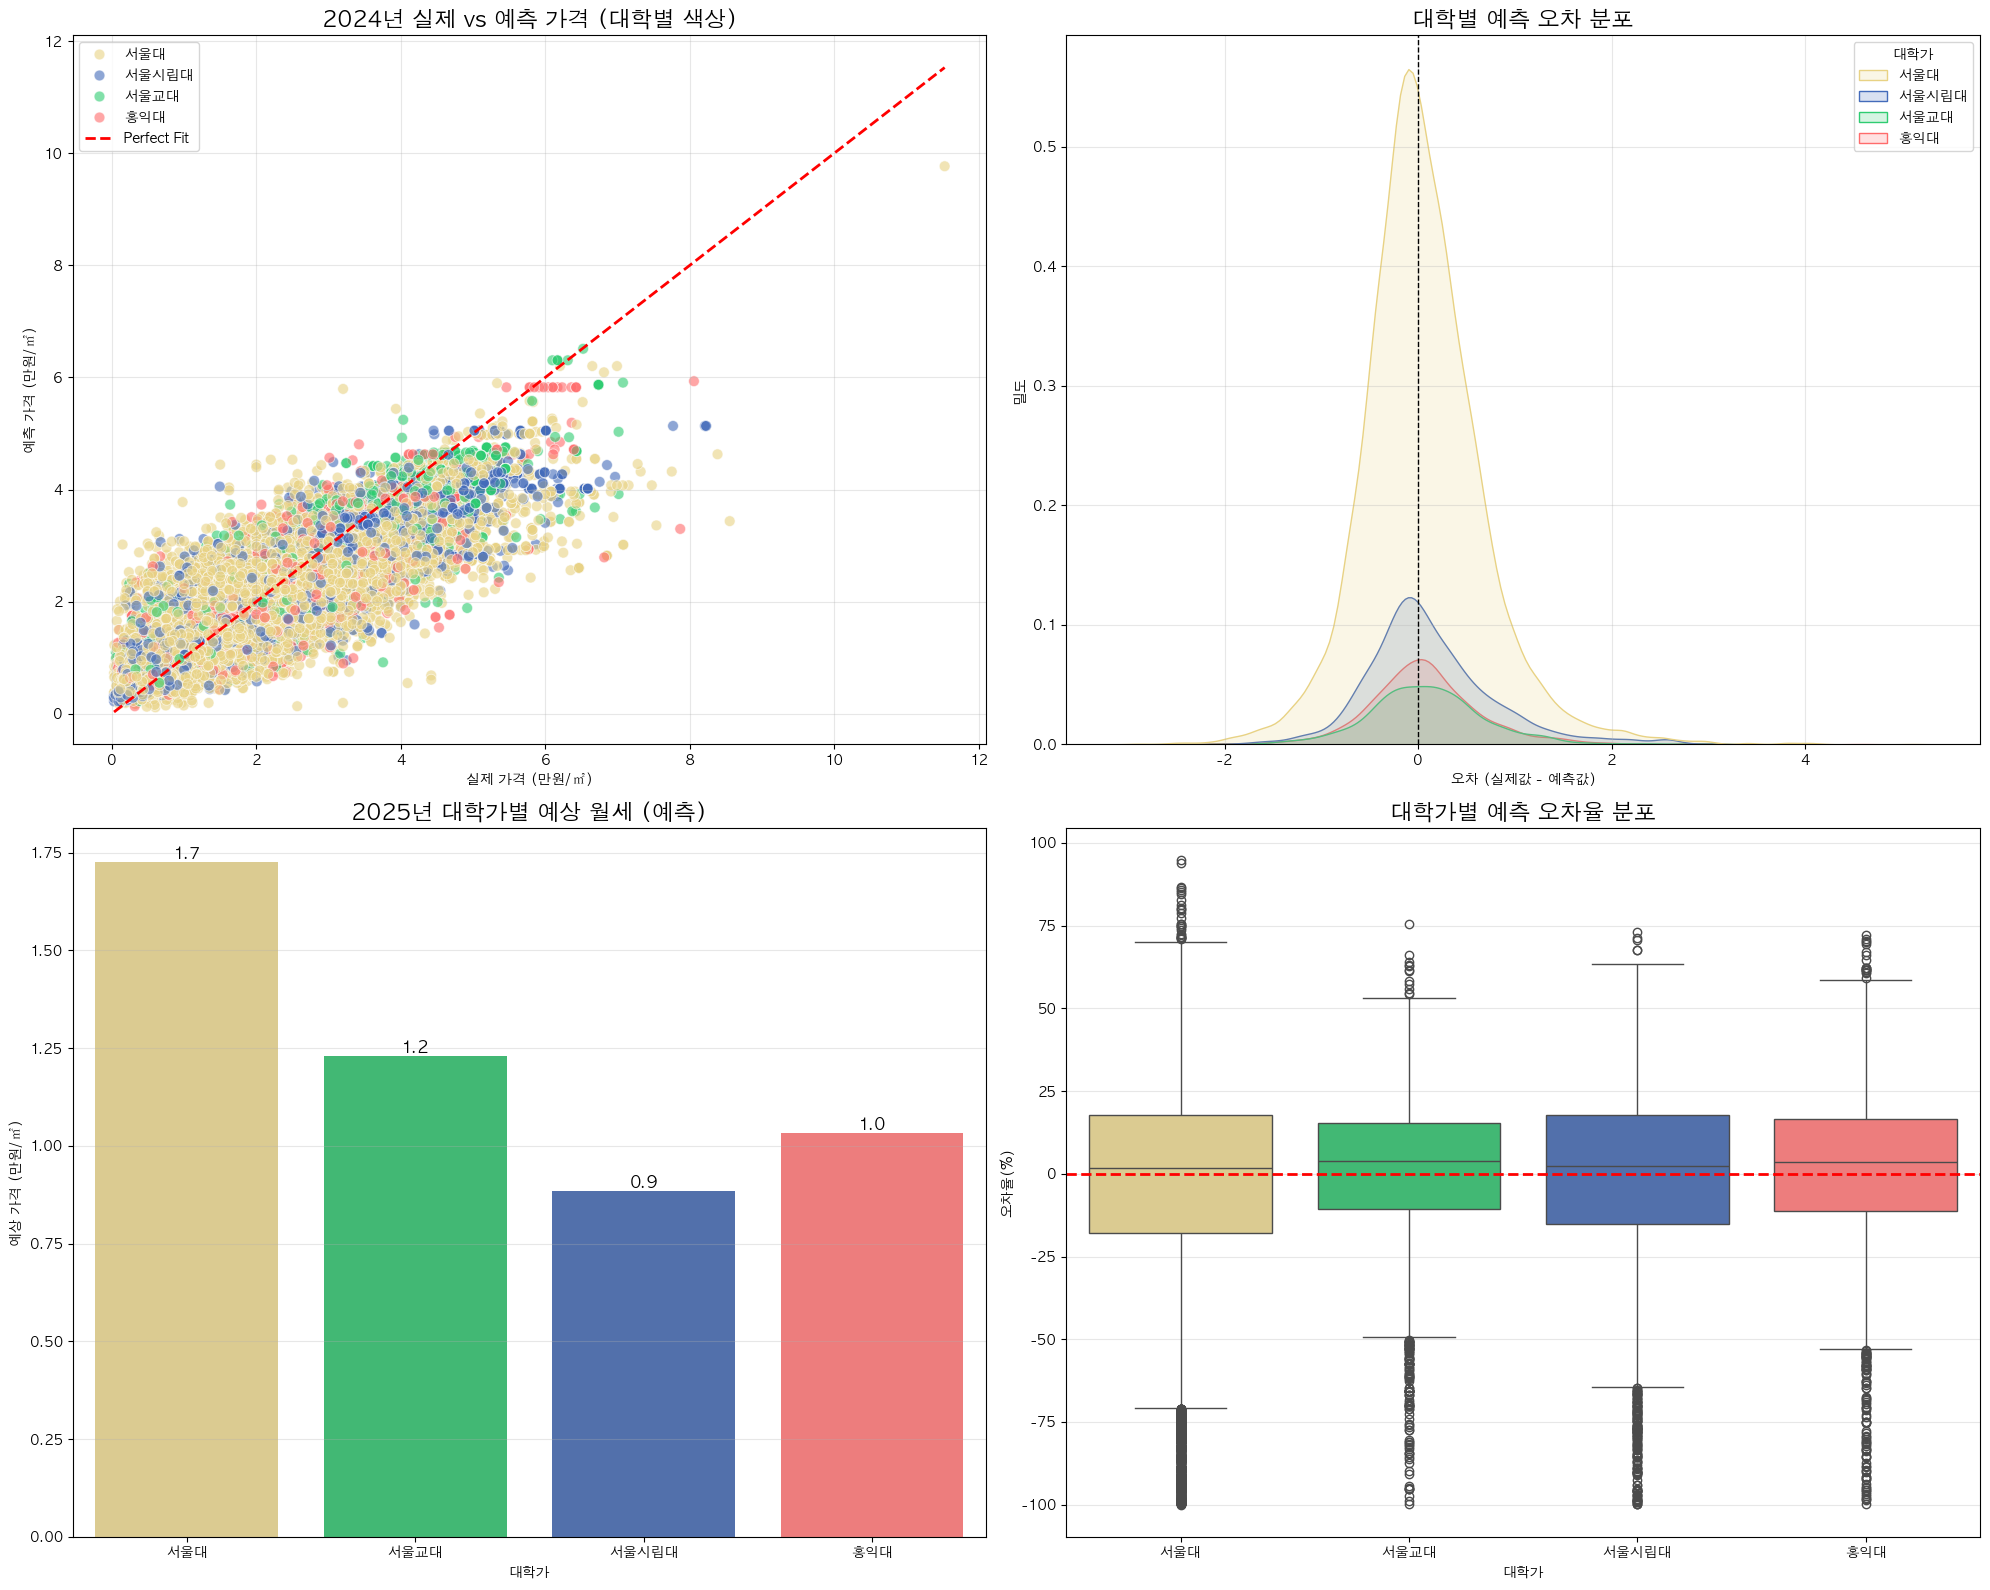

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 대학별 지정 색상 매핑 (요청하신 순서 반영)
# ---------------------------------------------------------
# 서울대(노랑), 서울교대(초록), 서울시립대(파랑), 홍익대(빨강)
univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

# ---------------------------------------------------------
# 2. 데이터 준비 (이전 단계 데이터 활용)
# ---------------------------------------------------------
# test_data와 예측 결과를 합칩니다.
comparison_df = test_data.copy()
comparison_df['실제값'] = y_test
comparison_df['예측값'] = y_pred
comparison_df['오차'] = comparison_df['실제값'] - comparison_df['예측값']
comparison_df['오차율(%)'] = (comparison_df['오차'] / comparison_df['실제값']) * 100

# 대학가 컬럼 복구 (인덱스 기준)
comparison_df['대학가'] = df_analysis.loc[comparison_df.index, '대학가']

# ---------------------------------------------------------
# 3. 시각화 (지정된 색상 적용)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# (1) 실제값 vs 예측값 산점도 (대학별 색상 적용)
# hue='대학가'를 통해 점마다 해당 대학의 색깔을 입힙니다.
sns.scatterplot(
    x='실제값', y='예측값', 
    data=comparison_df, 
    hue='대학가', 
    palette=univ_palette,  # ★ 지정된 색상 적용
    alpha=0.6, 
    s=60,
    ax=axes[0, 0]
)
# 기준선 (y=x)
min_val = min(comparison_df['실제값'].min(), comparison_df['예측값'].min())
max_val = max(comparison_df['실제값'].max(), comparison_df['예측값'].max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[0, 0].set_title('2024년 실제 vs 예측 가격 (대학별 색상)', fontsize=16)
axes[0, 0].set_xlabel('실제 가격 (만원/㎡)')
axes[0, 0].set_ylabel('예측 가격 (만원/㎡)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='upper left')

# (2) 오차(Residual) 분포 (대학별 KDE Plot)
# 대학별로 오차 분포가 어떻게 다른지 선 그래프(밀도함수)로 보여줍니다.
sns.kdeplot(
    data=comparison_df, 
    x='오차', 
    hue='대학가', 
    palette=univ_palette,  # ★ 지정된 색상 적용
    fill=True, 
    alpha=0.2, 
    ax=axes[0, 1]
)
axes[0, 1].axvline(x=0, color='black', linestyle='--', lw=1)
axes[0, 1].set_title('대학별 예측 오차 분포', fontsize=16)
axes[0, 1].set_xlabel('오차 (실제값 - 예측값)')
axes[0, 1].set_ylabel('밀도')
axes[0, 1].grid(True, alpha=0.3)

# (3) 2025년 예측 결과 (막대 그래프)
# 2025년 예측 데이터(df_future)가 있다고 가정하고 그립니다. 
# (만약 df_future가 없다면 이 부분은 건너뛰거나 위 코드 실행 후 다시 실행해주세요)
if 'df_future' in locals():
    sns.barplot(
        x='대학가', 
        y='2025_예측_단위면적당_월세', 
        data=df_future, 
        palette=univ_palette, # ★ 지정된 색상 적용
        ax=axes[1, 0],
        order=list(univ_palette.keys()) # 순서 고정
    )
    # 값 표시
    for p in axes[1, 0].patches:
        axes[1, 0].annotate(f'{p.get_height():.1f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('2025년 대학가별 예상 월세 (예측)', fontsize=16)
    axes[1, 0].set_ylabel('예상 가격 (만원/㎡)')
    axes[1, 0].grid(True, axis='y', alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, '2025년 예측 데이터가 생성되지 않았습니다.', ha='center')

# (4) 대학가별 오차율 Boxplot
# 오차율이 너무 큰 이상치 제외 (-100 ~ 100% 사이)
filtered_df = comparison_df[comparison_df['오차율(%)'].between(-100, 100)]

sns.boxplot(
    x='대학가', 
    y='오차율(%)', 
    data=filtered_df, 
    palette=univ_palette, # ★ 지정된 색상 적용
    ax=axes[1, 1],
    order=list(univ_palette.keys()) # 순서 고정
)
axes[1, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 1].set_title('대학가별 예측 오차율 분포', fontsize=16)
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


--- 2025년 대학가별 단위면적당 월세 예측 결과 ---
     대학가  2025_예측_단위면적당_월세
0    서울대          1.727495
1  서울시립대          0.883445
2   서울교대          1.229103
3    홍익대          1.033119


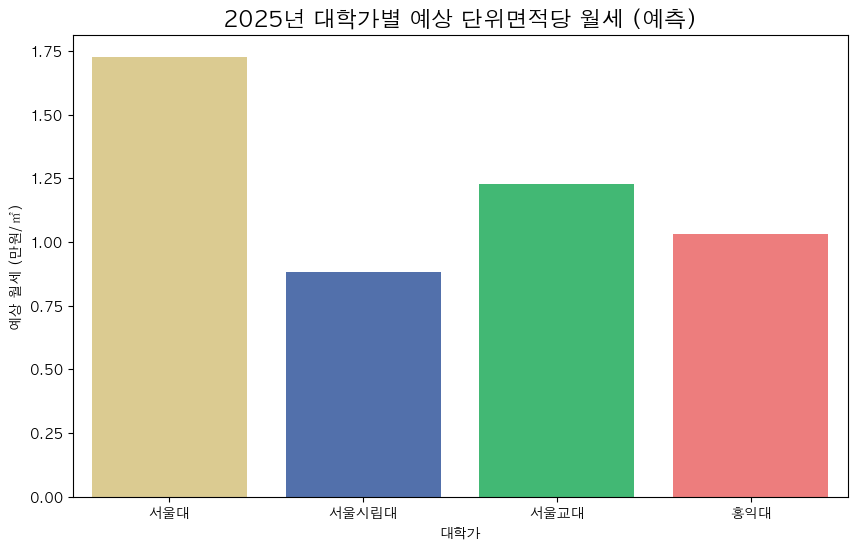

In [54]:
# 6. 2025년 예측을 위한 가상의 입력 데이터 생성
# 예: 각 대학가별 평균적인 건물 스펙(면적, 보증금 등)을 가정하여 2025년 월세 예측
universities = ['서울대', '서울시립대', '서울교대', '홍익대']
future_predictions = []

univ_palette = {
    '서울대': '#E8D284',
    '서울교대': '#2ECC71',
    '서울시립대': '#436BBA',
    '홍익대': '#FF6B6B'
}

# 각 대학가별로 대표적인 샘플 데이터를 생성 (평균값 활용)
for univ in universities:
    # 해당 대학가의 평균 면적 및 보증금 계산
    univ_mean_area = df_analysis[df_analysis['대학가'] == univ]['임대면적'].mean()
    univ_mean_deposit = df_analysis[df_analysis['대학가'] == univ]['보증금(만원)'].mean()
    
    # 입력 데이터프레임 생성 (One-Hot Encoding 컬럼 포함)
    input_row = pd.DataFrame(0, index=[0], columns=X_train.columns)
    input_row['접수년도'] = 2025
    input_row['임대면적'] = univ_mean_area
    input_row['보증금(만원)'] = univ_mean_deposit
    
    # 해당 대학가 및 건물용도(예: 아파트나 원룸 등 대표값) 더미 변수 설정
    # 컬럼명이 '대학가_서울대' 와 같은 형식인지 확인 필요
    if f'대학가_{univ}' in input_row.columns:
        input_row[f'대학가_{univ}'] = 1
    
    # 예측 수행
    pred_price = model.predict(input_row)[0]
    future_predictions.append({'대학가': univ, '2025_예측_단위면적당_월세': pred_price})

# 결과 출력
df_future = pd.DataFrame(future_predictions)
print("\n--- 2025년 대학가별 단위면적당 월세 예측 결과 ---")
print(df_future)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='대학가', y='2025_예측_단위면적당_월세', data=df_future, palette=univ_palette)
plt.title('2025년 대학가별 예상 단위면적당 월세 (예측)', fontsize=16)
plt.ylabel('예상 월세 (만원/㎡)')
plt.show()

# Why?

## Supply-Side Analysis

### data loading

In [38]:
file_path = './Data/서울시 건축물대장 총괄표제부'
data = pd.read_csv(file_path + '.csv', encoding='cp949', low_memory=False)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19810 entries, 0 to 19809
Data columns (total 53 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   대지위치          19810 non-null  object 
 1   시군구코드명        19564 non-null  object 
 2   법정동코드명        19564 non-null  object 
 3   대지구분코드명       19810 non-null  object 
 4   주지번           19810 non-null  int64  
 5   부지번           19810 non-null  int64  
 6   특수지명          26 non-null     object 
 7   블록번호          9 non-null      object 
 8   로트번호          1 non-null      float64
 9   새주소도로코드명      12378 non-null  object 
 10  새주소법정동코드명     12378 non-null  object 
 11  새주소지상지하구분코드명  19655 non-null  object 
 12  새주소주지번        13423 non-null  float64
 13  새주소부지번        8166 non-null   float64
 14  건축물대장일련번호     19810 non-null  object 
 15  대장구분코드명       19799 non-null  object 
 16  대장종류코드명       19810 non-null  object 
 17  대지면적          12215 non-null  float64
 18  건축면적          16011 non-nu

In [40]:
data['기타용도내용']

0                                                       학교
1                                                   아파트,상가
2                                                      아파트
3                                              근린생활시설, 여인숙
4                                             아파트 및 근린생활시설
                               ...                        
19805    공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및...
19806                                숙박시설(판매,위락,문화및집회,운동등)
19807                                            공동주택(아파트)
19808                                           근린생활시설, 주택
19809                                             공동주택,아파트
Name: 기타용도내용, Length: 19810, dtype: object

In [41]:
selected_columns = ['허가일자', '새주소법정동코드명', '기타용도내용']
data = data[selected_columns]
data

,허가일자,새주소법정동코드명,기타용도내용
0,NaN,대현동,학교
1,1992-06-12,방화동,"아파트,상가"
2,1991-12-28,방화동,아파트
3,NaN,구로동,"근린생활시설, 여인숙"
4,NaN,신월동,아파트 및 근린생활시설
...,...,...,...
19805,2014-09-11,전농동,"공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및..."
19806,1986-06-02,잠실동,"숙박시설(판매,위락,문화및집회,운동등)"
19807,2004-12-24,강일동,공동주택(아파트)
19808,NaN,NaN,"근린생활시설, 주택"


In [42]:
data.isnull().sum()
data = data.dropna()
data = data.copy()


In [43]:
# '허가일자'를 날짜 형식으로 변환합니다.
# errors='coerce'는 변환할 수 없는 값이 있을 경우 오류 대신 결측치(NaT)로 만듭니다.
data['허가일자'] = pd.to_datetime(data['허가일자'], errors='coerce')

# 날짜에서 '연도'만 추출하여 새 컬럼을 만듭니다.
data['허가연도'] = data['허가일자'].dt.year

# 변환에 실패했거나 연도가 없는 데이터는 분석에서 제외합니다.
data = data.dropna(subset=['허가연도'])

# 연도를 정수형으로 변환합니다 (예: 2020.0 -> 2020).
data['허가연도'] = data['허가연도'].astype(int)

print("'허가연도' 컬럼 생성 완료:")
print(data[['허가일자', '허가연도']].head())

data

'허가연도' 컬럼 생성 완료:
         허가일자  허가연도
1  1992-06-12  1992
2  1991-12-28  1991
10 2003-12-30  2003
18 2015-09-11  2015
21 2022-02-24  2022


,허가일자,새주소법정동코드명,기타용도내용,허가연도
1,1992-06-12,방화동,"아파트,상가",1992
2,1991-12-28,방화동,아파트,1991
10,2003-12-30,장지동,아파트,2003
18,2015-09-11,항동,도시형생활주택(원룸형),2015
21,2022-02-24,공항동,공동주택(아파트),2022
...,...,...,...,...
19804,2018-10-08,원효로1가,"공동주택,제1종근린생활시설,문화및집회시설",2018
19805,2014-09-11,전농동,"공동주택(아파트),판매시설(상점,백화점),업무시설(오피스텔,오피스),숙박시설,문화및...",2014
19806,1986-06-02,잠실동,"숙박시설(판매,위락,문화및집회,운동등)",1986
19807,2004-12-24,강일동,공동주택(아파트),2004


In [44]:
# 1. 분류 규칙을 담은 함수를 정의합니다.
def classify_building_type(text):
    # text가 비어있는 경우(NaN)를 대비한 예외 처리
    if pd.isna(text):
        return '기타'
    
    # 1순위: '아파트' 확인
    if '아파트' in text:
        return '아파트'
    # 2순위: '오피스텔' 확인
    elif '오피스텔' in text:
        return '오피스텔'
    # 3순위: '다세대' 또는 '다가구' 확인
    elif '다세대' in text or '다가구' in text:
        return '다세대/다가구'
    # 그 외
    else:
        return '기타'

# 2. '기타용도내용' 컬럼에 함수를 적용하여 '세부용도'라는 새 컬럼을 생성합니다.
data['세부용도'] = data['기타용도내용'].apply(classify_building_type)

# 3. 분석에 필요한 주거 형태만 필터링합니다.
target_types = ['아파트', '오피스텔', '다세대/다가구']
analysis_data = data[data['세부용도'].isin(target_types)].copy()

# --- 결과 확인 ---
print("--- 분류 결과 (상위 5개) ---")
print(analysis_data[['기타용도내용', '세부용도']].head())

print("\n--- 세부용도별 데이터 개수 ---")
print(analysis_data['세부용도'].value_counts())

--- 분류 결과 (상위 5개) ---
       기타용도내용 세부용도
1      아파트,상가  아파트
2         아파트  아파트
10        아파트  아파트
21  공동주택(아파트)  아파트
23        아파트  아파트

--- 세부용도별 데이터 개수 ---
세부용도
아파트        1254
다세대/다가구     956
오피스텔        118
Name: count, dtype: int64


In [45]:
import pandas as pd


# 2. .map() 함수에 사용하기 편하도록 딕셔너리를 역으로 만듭니다.
dong_to_univ_map = {dong: univ for univ, dongs in univ_dong_map.items() for dong in dongs}

# 3. .map() 함수를 사용하여 '대학가' 컬럼을 한 번에 생성합니다.
data['대학가'] = data['새주소법정동코드명'].map(dong_to_univ_map)

# 4. '대학가' 이름이 할당되지 않은(분석 대상이 아닌) 행들을 제거하고,
#    분석용 데이터프레임을 복사본(.copy())으로 만듭니다.
analysis_data = data.dropna(subset=['대학가']).copy()


# --- 최종 결과 확인 ---
print("--- 최종 분석용 데이터 정보 ---")
analysis_data.info()

print("\n--- 각 대학가별 데이터 개수 ---")
print(analysis_data['대학가'].value_counts())

print("\n--- 최종 데이터 샘플 ---")
# '새주소법정동코드명'이 '대학가'에 올바르게 매칭되었는지 확인합니다.
print(analysis_data[['새주소법정동코드명', '대학가']].head())

--- 최종 분석용 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 81 to 19809
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   허가일자       239 non-null    datetime64[ns]
 1   새주소법정동코드명  239 non-null    object        
 2   기타용도내용     239 non-null    object        
 3   허가연도       239 non-null    int64         
 4   세부용도       239 non-null    object        
 5   대학가        239 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 13.1+ KB

--- 각 대학가별 데이터 개수 ---
대학가
서울대      132
서울교대      57
서울시립대     29
홍익대       21
Name: count, dtype: int64

--- 최종 데이터 샘플 ---
    새주소법정동코드명    대학가
81        서교동    홍익대
236      답십리동  서울시립대
422       서초동   서울교대
529       서초동   서울교대
852       신림동    서울대


In [46]:
# '허가연도', '대학가', '세부용도'를 기준으로 신축 허가 건수를 집계합니다.
supply_trend = analysis_data.groupby(['허가연도', '대학가', '세부용도']).size().reset_index(name='신축허가건수')

print("--- 연도별/대학가별/유형별 신축 허가 건수 집계 결과 ---")
print(supply_trend.head(10))

--- 연도별/대학가별/유형별 신축 허가 건수 집계 결과 ---
   허가연도  대학가     세부용도  신축허가건수
0  1983  서울대       기타       2
1  1983  홍익대       기타       1
2  1991  서울대      아파트       1
3  1992  서울대      아파트       1
4  1993  서울대  다세대/다가구       2
5  1994  서울대       기타       2
6  1994  홍익대       기타       1
7  1994  홍익대  다세대/다가구       2
8  1995  서울대       기타       2
9  1996  서울대       기타       1


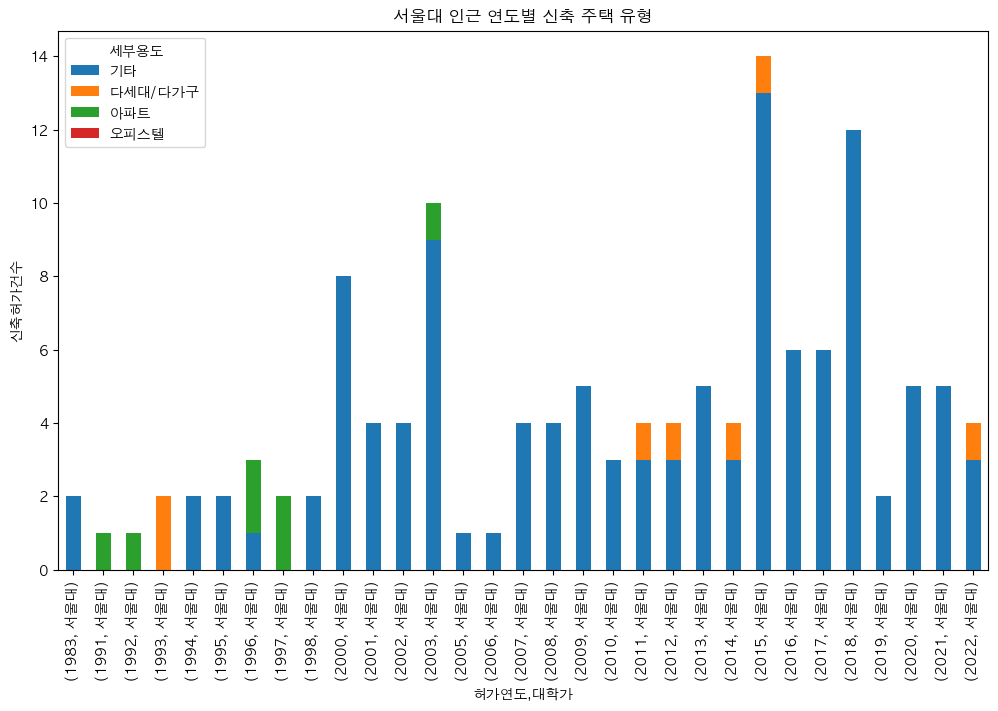

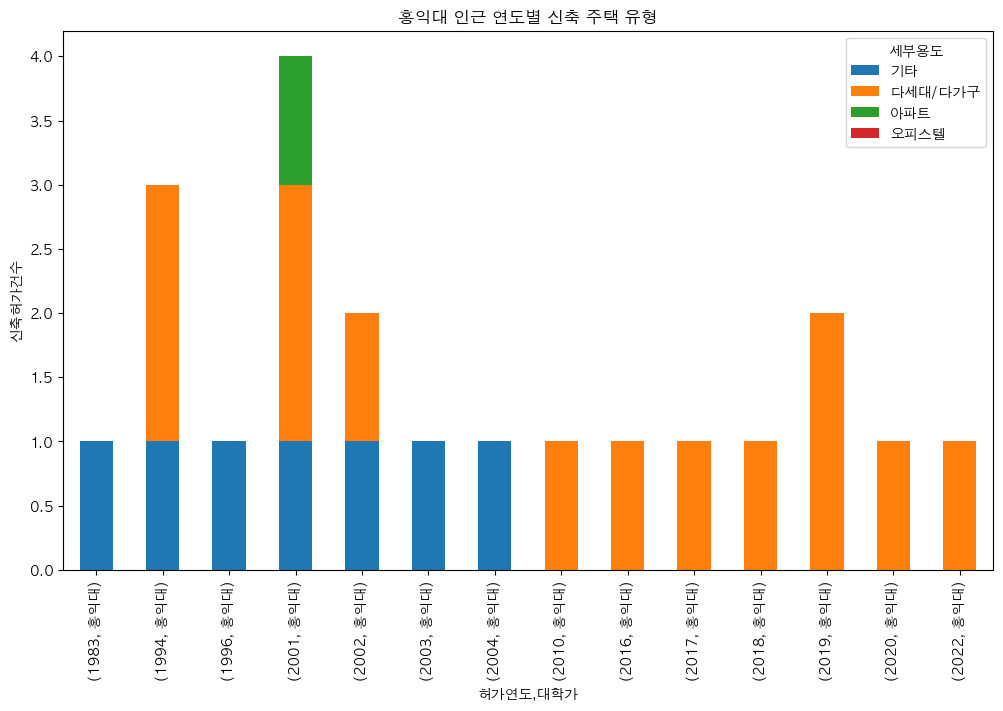

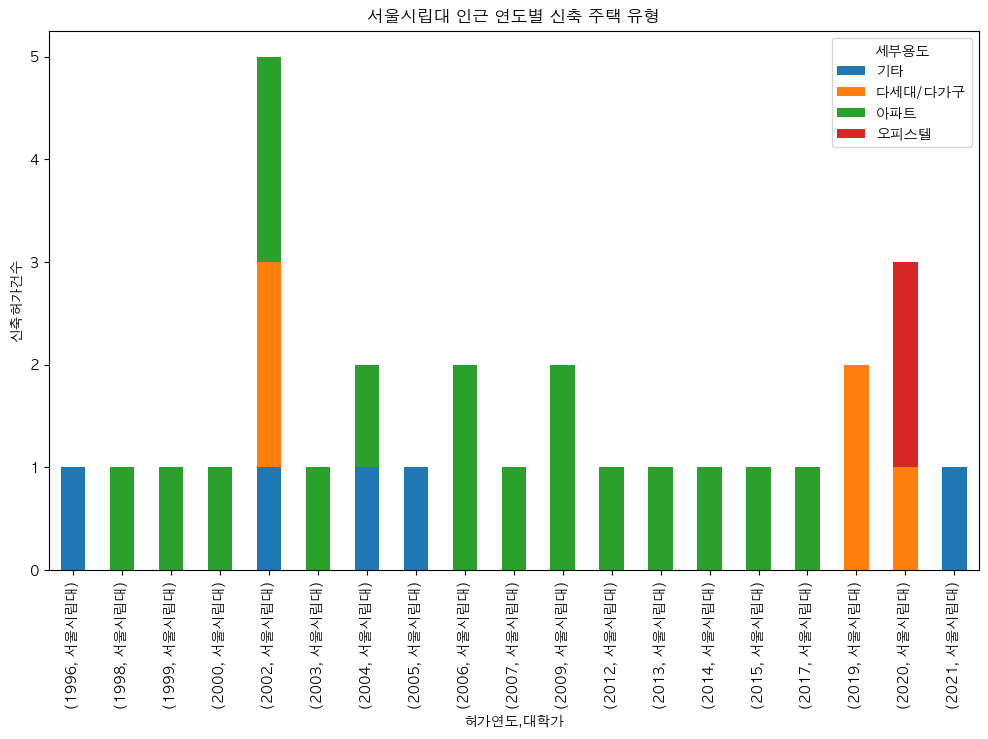

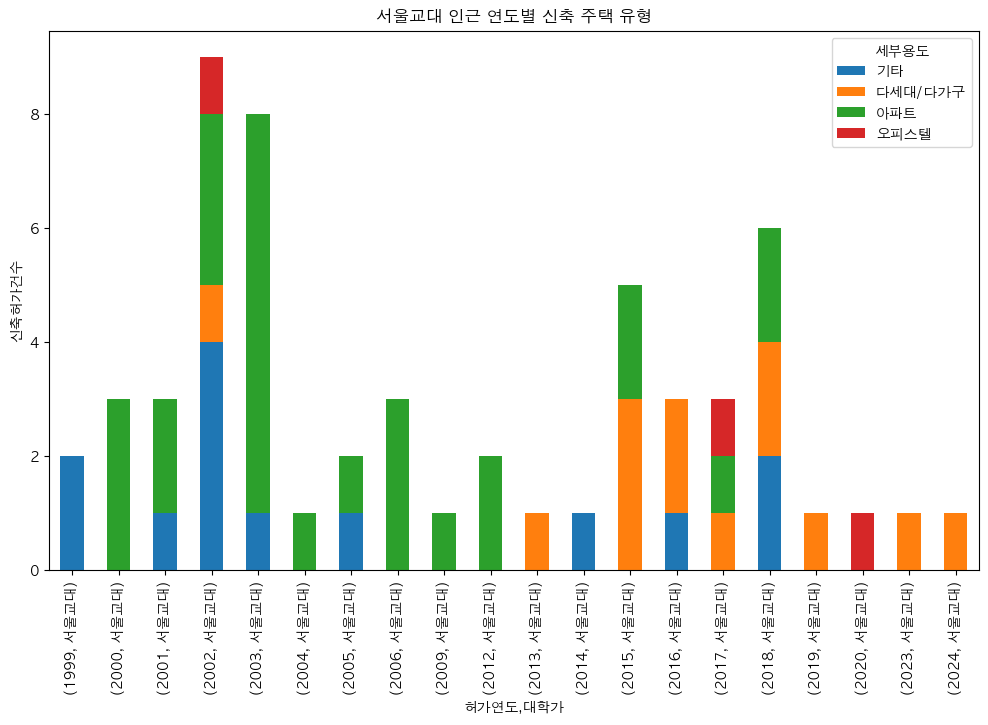

In [47]:
# 시각화를 위해 데이터를 피벗(pivot)합니다.
supply_pivot = supply_trend.pivot_table(index=['허가연도', '대학가'], 
                                        columns='세부용도', 
                                        values='신축허가건수',
                                        fill_value=0)

# 각 대학가별로 누적 막대그래프 그리기
for univ in supply_pivot.index.get_level_values('대학가').unique():
    supply_pivot.loc[(slice(None), univ), :].plot(
        kind='bar', 
        stacked=True, 
        figsize=(12, 7),
        title=f'{univ} 인근 연도별 신축 주택 유형'
    )
    plt.ylabel('신축허가건수')
    plt.show()